In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.core.algorithms import duplicated
from tensorflow.python.ops.gen_array_ops import upper_bound

In [3]:
df=pd.read_csv("telecom_data.csv")
df.head()

,Transaction_ID,Date,Product_Category,Price,Customer_Satisfaction
0,TXN1057,7/20/2026,Network_Service,44.982481,2.0
1,TXN1039,2/10/2026,Data_Plan,33.833828,1.0
2,TXN1321,11/21/2026,Network_Service,37.535748,5.0
3,TXN1281,6/6/2026,Support_Ticket,41.362726,3.0
4,TXN1280,7/4/2026,Support_Ticket,42.042483,2.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         510 non-null    object 
 1   Date                   510 non-null    object 
 2   Product_Category       510 non-null    object 
 3   Price                  485 non-null    float64
 4   Customer_Satisfaction  483 non-null    float64
dtypes: float64(2), object(3)
memory usage: 20.1+ KB


In [7]:
df.isna().sum()

Transaction_ID            0
Date                      0
Product_Category          0
Price                    25
Customer_Satisfaction    27
dtype: int64

In [9]:
df.describe()

,Price,Customer_Satisfaction
count,485.000000,483.000000
mean,100.958452,3.004141
std,500.752903,1.431704
min,1.380990,1.000000
25%,40.060644,2.000000
50%,49.816298,3.000000
75%,60.193966,4.000000
max,5000.000000,5.000000


In [12]:
(df["Price"]==0).sum()

np.int64(0)

In [13]:
(df["Customer_Satisfaction"]==0).sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(10)

In [25]:
df[df.duplicated(subset="Transaction_ID" ,keep=False)]


,Transaction_ID,Date,Product_Category,Price,Customer_Satisfaction
12,TXN1361,7/11/2026,Network_Service,40.940222,4.0
22,TXN1471,4/17/2026,Support_Ticket,47.834594,4.0
58,TXN1131,1/8/2026,Network_Service,48.047854,NaN
86,TXN1410,4/11/2026,Data_Plan,43.335601,NaN
123,TXN1129,11/28/2026,Support_Ticket,45.345999,2.0
163,TXN1361,7/11/2026,Network_Service,40.940222,4.0
203,TXN1170,3/8/2026,Support_Ticket,54.840778,5.0
261,TXN1036,11/16/2026,Support_Ticket,42.921022,1.0
315,TXN1131,1/8/2026,Network_Service,48.047854,NaN
326,TXN1455,9/28/2026,Data_Plan,27.452856,3.0


In [26]:
df[df.duplicated()]

,Transaction_ID,Date,Product_Category,Price,Customer_Satisfaction
163,TXN1361,7/11/2026,Network_Service,40.940222,4.0
315,TXN1131,1/8/2026,Network_Service,48.047854,NaN
354,TXN1410,4/11/2026,Data_Plan,43.335601,NaN
394,TXN1170,3/8/2026,Support_Ticket,54.840778,5.0
431,TXN1330,1/11/2026,Network_Service,51.489985,2.0
476,TXN1479,9/13/2026,Support_Ticket,72.559895,4.0
480,TXN1455,9/28/2026,Data_Plan,27.452856,3.0
497,TXN1129,11/28/2026,Support_Ticket,45.345999,2.0
503,TXN1471,4/17/2026,Support_Ticket,47.834594,4.0
507,TXN1036,11/16/2026,Support_Ticket,42.921022,1.0


In [27]:
df=df.drop_duplicates()

In [28]:
df

,Transaction_ID,Date,Product_Category,Price,Customer_Satisfaction
0,TXN1057,7/20/2026,Network_Service,44.982481,2.0
1,TXN1039,2/10/2026,Data_Plan,33.833828,1.0
2,TXN1321,11/21/2026,Network_Service,37.535748,5.0
3,TXN1281,6/6/2026,Support_Ticket,41.362726,3.0
4,TXN1280,7/4/2026,Support_Ticket,42.042483,2.0
...,...,...,...,...,...
504,TXN1016,9/16/2026,Support_Ticket,NaN,2.0
505,TXN1040,8/22/2026,Data_Plan,39.270444,2.0
506,TXN1304,2/2/2026,Hardware,51.160525,4.0
508,TXN1343,6/28/2026,Hardware,25.077199,5.0


In [35]:
df.isnull().sum()

Transaction_ID            0
Date                      0
Product_Category          0
Price                    25
Customer_Satisfaction    25
dtype: int64

In [31]:
df

,Transaction_ID,Date,Product_Category,Price,Customer_Satisfaction
0,TXN1057,7/20/2026,Network_Service,44.982481,2.0
1,TXN1039,2/10/2026,Data_Plan,33.833828,1.0
2,TXN1321,11/21/2026,Network_Service,37.535748,5.0
3,TXN1281,6/6/2026,Support_Ticket,41.362726,3.0
4,TXN1280,7/4/2026,Support_Ticket,42.042483,2.0
...,...,...,...,...,...
504,TXN1016,9/16/2026,Support_Ticket,NaN,2.0
505,TXN1040,8/22/2026,Data_Plan,39.270444,2.0
506,TXN1304,2/2/2026,Hardware,51.160525,4.0
508,TXN1343,6/28/2026,Hardware,25.077199,5.0


<Axes: xlabel='Price'>

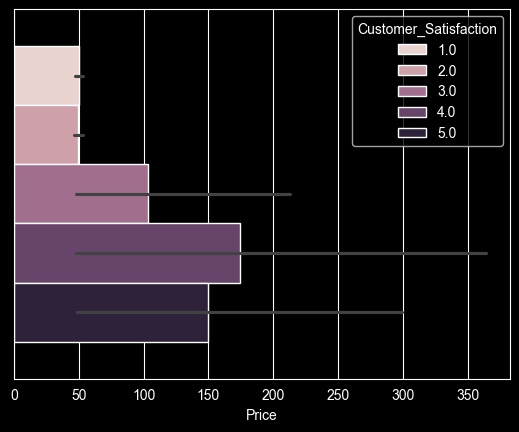

In [50]:
sns.barplot(df,x="Price",hue="Customer_Satisfaction")

In [52]:
df["Customer_Satisfaction"].max()

np.float64(5.0)

In [53]:
df["Customer_Satisfaction"].min()

np.float64(1.0)

In [54]:
df["Price"].max()

np.float64(5000.0)

In [55]:
df["Price"].min()

np.float64(1.380989898963911)

In [62]:
df[df["Product_Category"]=="Data_Plan"]

,Transaction_ID,Date,Product_Category,Price,Customer_Satisfaction
1,TXN1039,2/10/2026,Data_Plan,33.833828,1.0
11,TXN1109,6/15/2026,Data_Plan,54.609493,3.0
13,TXN1365,4/27/2026,Data_Plan,53.816313,4.0
16,TXN1199,4/24/2026,Data_Plan,78.142563,1.0
19,TXN1084,11/9/2026,Data_Plan,67.447456,4.0
...,...,...,...,...,...
492,TXN1146,9/2/2026,Data_Plan,64.626796,5.0
494,TXN1191,3/21/2026,Data_Plan,37.875526,2.0
500,TXN1058,4/13/2026,Data_Plan,42.875820,5.0
505,TXN1040,8/22/2026,Data_Plan,39.270444,2.0


In [70]:
median_value=df["Customer_Satisfaction"].median()

In [71]:
df["Customer_Satisfaction"]=df["Customer_Satisfaction"].fillna(median_value)

C:\Users\priya\AppData\Local\Temp\ipykernel_2772\2661283680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Customer_Satisfaction"]=df["Customer_Satisfaction"].fillna(median_value)


In [73]:
df["Customer_Satisfaction"].isna().sum()

np.int64(0)

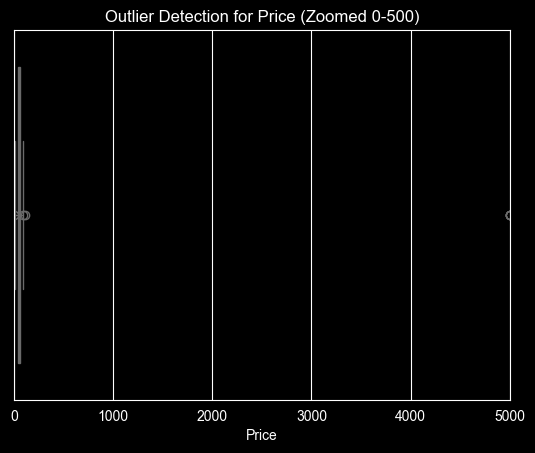

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the boxplot
sns.boxplot(x=df['Price'])

# Set the x-axis limits between 0 and 500
plt.xlim(0, 5000)

plt.title('Outlier Detection for Price (Zoomed 0-500)')
plt.show()

In [87]:
import plotly.express as px
fig = px.box(df, x="Price", color="Product_Category",
             title="Outliers by Category",
             hover_data=["Transaction_ID"])
fig.show()

In [100]:
Q1=df["Price"].quantile(0.25)
Q3=df["Price"].quantile(0.75)

IQR=Q3-Q1

Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR

outliers = df[(df["Price"]<Lower_bound) | (df["Price"]>Upper_bound)]
print(outliers)

    Transaction_ID        Date Product_Category        Price  \
152        TXN1002   2/27/2026  Network_Service  5000.000000   
162        TXN1290   7/23/2026  Network_Service    96.183212   
205        TXN1021   7/23/2026  Network_Service   107.790972   
231        TXN1003  11/20/2026        Data_Plan  5000.000000   
282        TXN1004   2/12/2026        Data_Plan  5000.000000   
374        TXN1074   10/6/2026  Network_Service     1.380990   
417        TXN1001  11/10/2026   Support_Ticket  5000.000000   
486        TXN1000   10/2/2026        Data_Plan  5000.000000   

     Customer_Satisfaction  
152                    4.0  
162                    1.0  
205                    2.0  
231                    5.0  
282                    5.0  
374                    2.0  
417                    4.0  
486                    3.0  


In [98]:
df["Price"].max()

np.float64(5000.0)

In [101]:
print(df['Price'].describe())

count     475.000000
mean      102.084380
std       505.944178
min         1.380990
25%        39.555237
50%        50.078655
75%        60.260033
max      5000.000000
Name: Price, dtype: float64


In [104]:
# Calculate the 95th percentile
upper_limit = df['Price'].quantile(0.95)

# Cap the values
df['Price'] = df['Price'].clip(upper=upper_limit)

C:\Users\priya\AppData\Local\Temp\ipykernel_2772\2534320775.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'].clip(upper=upper_limit)


In [105]:
print(df['Price'].describe())

count    475.000000
mean      50.028223
std       14.963834
min        1.380990
25%       39.555237
50%       50.078655
75%       60.260033
max       77.856808
Name: Price, dtype: float64


outliers are done , now we will do NA value handling on price data